# Decision Tree 

## 1. Imports & Data Preprocessing

In [1]:

import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# ── Configuration (mirrors process_data.ipynb exactly) ───────────────────────
SEED        = 42
WINDOW_SIZE = 20
STEP_SIZE   = 5
DATA_PATH   = "trip_*.csv"   # adjust path as needed

# ── Load & preprocess all trip CSVs ──────────────────────────────────────────
files = glob.glob(DATA_PATH)
print(f"Found {len(files)} CSV files.")

all_samples = []
for fn in sorted(files):
    df = pd.read_csv(fn)
    df["mag"]       = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
    df["jerk"]      = df["mag"].diff().fillna(0)
    df["gps_speed"] = df["gps_speed"].fillna(0)
    for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        w = df.iloc[i : i + WINDOW_SIZE]
        label = w["label"].mode()[0]
        all_samples.append({
            "label":       label,
            "avg_speed":   float(w["gps_speed"].mean()),
            "max_force":   float(w["mag"].max()),
            "std_force":   float(w["mag"].std()),
            "min_force":   float(w["mag"].min()),
            "avg_jerk":    float(w["jerk"].abs().mean()),
            "avg_lateral": float(w["acc_y"].abs().mean()),
            "max_lateral": float(w["acc_y"].abs().max()),
        })

dfm = pd.DataFrame(all_samples)
print(f"Total windows: {len(dfm)}")
print("Class distribution:")
print(dfm["label"].value_counts())

# ── Feature / label split & train-test split ─────────────────────────────────
from sklearn.model_selection import train_test_split

X = dfm.drop(columns=["label"])
y = dfm["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")


Found 6 CSV files.
Total windows: 9433
Class distribution:
label
Cruising      6380
Lane Left     1091
Braking        985
Lane Right     977
Name: count, dtype: int64

Train: 7546  |  Test: 1887


## 2. Model Training

In [2]:

import time
from sklearn.tree import DecisionTreeClassifier

MODEL_NAME = "Decision Tree"

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
model = DecisionTreeClassifier(random_state=SEED)
model.fit(X_train, y_train)
print(f"Training time: {time.time()-t0:.2f}s")
print(f"Tree depth: {model.get_depth()}  |  Leaves: {model.get_n_leaves()}")


Training time: 0.07s
Tree depth: 33  |  Leaves: 1448


## 3. Evaluation & Visualizations

In [3]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# Muted color palette — designed so RF (forest green) stands out when comparing
MODEL_COLOR   = "#c4a8c4"   # this model
ACCENT_COLOR  = "#5b8db8"   # secondary accent
classes = sorted(y.unique().tolist())

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {{acc:.4f}}")
print(f"Precision : {{prec:.4f}}")
print(f"Recall    : {{rec:.4f}}")
print(f"F1-Score  : {{f1:.4f}}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy  : {acc:.4f}
Precision : {prec:.4f}
Recall    : {rec:.4f}
F1-Score  : {f1:.4f}

Detailed Classification Report:
              precision    recall  f1-score   support

     Braking       0.74      0.75      0.75       198
    Cruising       0.83      0.81      0.82      1292
   Lane Left       0.39      0.44      0.41       204
  Lane Right       0.44      0.46      0.45       193

    accuracy                           0.73      1887
   macro avg       0.60      0.61      0.61      1887
weighted avg       0.73      0.73      0.73      1887



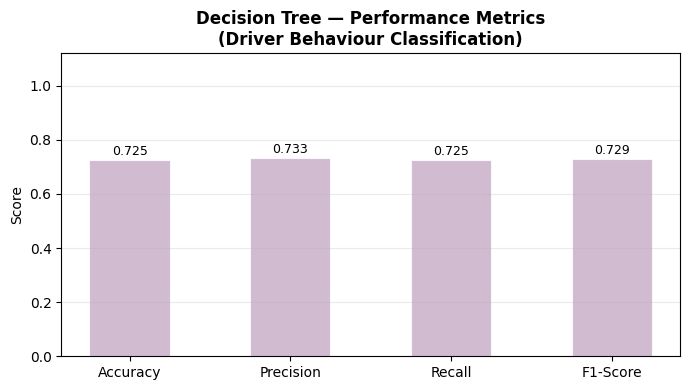

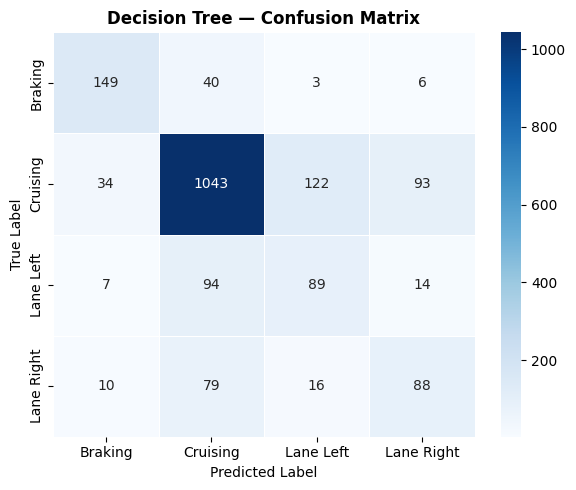

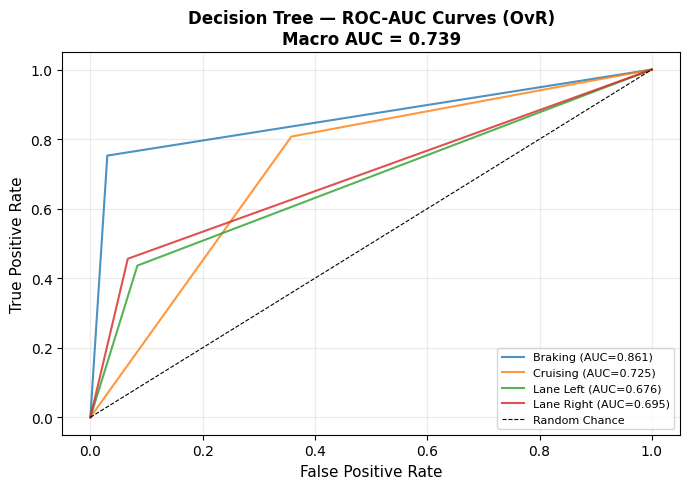


✅ Decision Tree — Macro ROC-AUC: 0.7392


In [4]:

# ── 1. Metrics Bar Chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_vals  = [acc, prec, rec, f1]
bars = ax.bar(metric_names, metric_vals, color=MODEL_COLOR,
              alpha=0.78, edgecolor="white", linewidth=0.8, width=0.5)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title(f"{MODEL_NAME} — Performance Metrics\n(Driver Behaviour Classification)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_metrics.png", dpi=150)
plt.show()

# ── 2. Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title(f"{MODEL_NAME} — Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_confusion.png", dpi=150)
plt.show()

# ── 3. ROC-AUC Curve (One-vs-Rest, macro) ────────────────────────────────────
y_bin = label_binarize(y_test, classes=classes)
cls_list = list(model.classes_)
prob_aligned = np.zeros((len(y_test), len(classes)))
for ci, c in enumerate(classes):
    if c in cls_list:
        prob_aligned[:, ci] = y_prob[:, cls_list.index(c)]

fig, ax = plt.subplots(figsize=(7, 5))
for ci, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, ci], prob_aligned[:, ci])
    auc = roc_auc_score(y_bin[:, ci], prob_aligned[:, ci])
    ax.plot(fpr, tpr, linewidth=1.5,
            label=f"{cls} (AUC={auc:.3f})", alpha=0.8)
macro_auc = roc_auc_score(y_bin, prob_aligned, average="macro", multi_class="ovr")
ax.plot([0,1],[0,1],"k--",linewidth=0.8,label="Random Chance")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"{MODEL_NAME} — ROC-AUC Curves (OvR)\nMacro AUC = {macro_auc:.3f}",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_roc.png", dpi=150)
plt.show()

print(f"\n✅ {MODEL_NAME} — Macro ROC-AUC: {macro_auc:.4f}")


# Gradient Boosting

In [5]:

import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# ── Configuration (mirrors process_data.ipynb exactly) ───────────────────────
SEED        = 42
WINDOW_SIZE = 20
STEP_SIZE   = 5
DATA_PATH   = "trip_*.csv"   # adjust path as needed

# ── Load & preprocess all trip CSVs ──────────────────────────────────────────
files = glob.glob(DATA_PATH)
print(f"Found {len(files)} CSV files.")

all_samples = []
for fn in sorted(files):
    df = pd.read_csv(fn)
    df["mag"]       = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
    df["jerk"]      = df["mag"].diff().fillna(0)
    df["gps_speed"] = df["gps_speed"].fillna(0)
    for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        w = df.iloc[i : i + WINDOW_SIZE]
        label = w["label"].mode()[0]
        all_samples.append({
            "label":       label,
            "avg_speed":   float(w["gps_speed"].mean()),
            "max_force":   float(w["mag"].max()),
            "std_force":   float(w["mag"].std()),
            "min_force":   float(w["mag"].min()),
            "avg_jerk":    float(w["jerk"].abs().mean()),
            "avg_lateral": float(w["acc_y"].abs().mean()),
            "max_lateral": float(w["acc_y"].abs().max()),
        })

dfm = pd.DataFrame(all_samples)
print(f"Total windows: {len(dfm)}")
print("Class distribution:")
print(dfm["label"].value_counts())

# ── Feature / label split & train-test split ─────────────────────────────────
from sklearn.model_selection import train_test_split

X = dfm.drop(columns=["label"])
y = dfm["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")

Found 6 CSV files.
Total windows: 9433
Class distribution:
label
Cruising      6380
Lane Left     1091
Braking        985
Lane Right     977
Name: count, dtype: int64

Train: 7546  |  Test: 1887


In [7]:

import time
from sklearn.ensemble import GradientBoostingClassifier

MODEL_NAME = "Gradient Boosting"

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
model = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)
print(f"Training time: {time.time()-t0:.2f}s")


Training time: 4.81s


In [8]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# Muted color palette — designed so RF (forest green) stands out when comparing
MODEL_COLOR   = "#c8a0a0"   # this model
ACCENT_COLOR  = "#5b8db8"   # secondary accent
classes = sorted(y.unique().tolist())

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {{acc:.4f}}")
print(f"Precision : {{prec:.4f}}")
print(f"Recall    : {{rec:.4f}}")
print(f"F1-Score  : {{f1:.4f}}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy  : {acc:.4f}
Precision : {prec:.4f}
Recall    : {rec:.4f}
F1-Score  : {f1:.4f}

Detailed Classification Report:
              precision    recall  f1-score   support

     Braking       0.81      0.70      0.75       198
    Cruising       0.76      0.98      0.85      1292
   Lane Left       0.70      0.07      0.12       204
  Lane Right       0.60      0.08      0.14       193

    accuracy                           0.76      1887
   macro avg       0.72      0.46      0.47      1887
weighted avg       0.74      0.76      0.69      1887



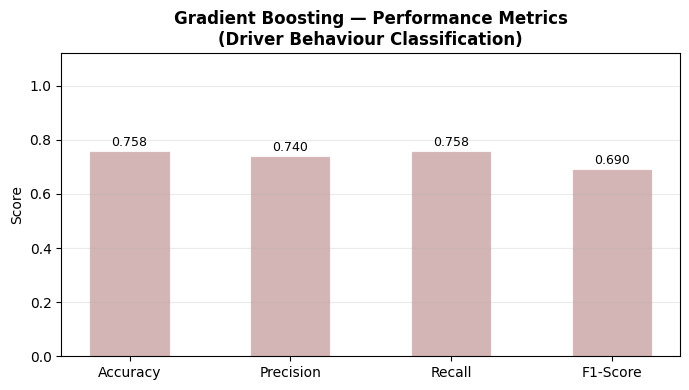

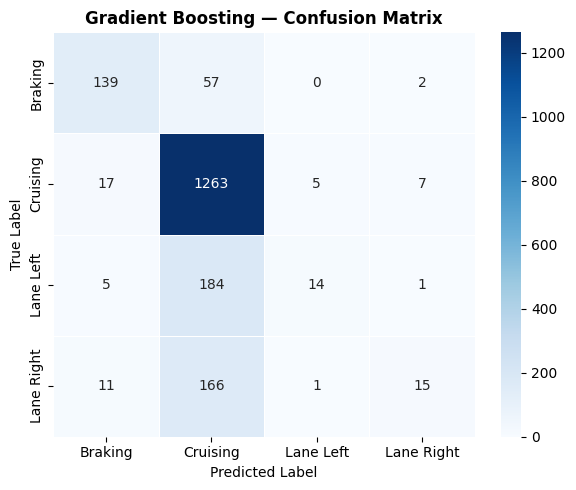

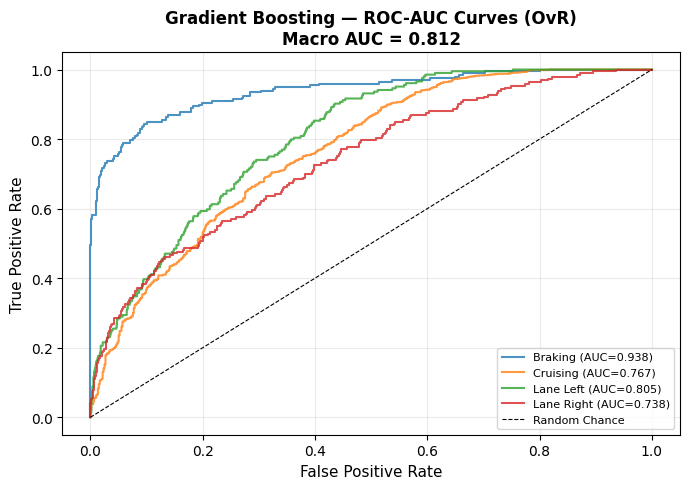


✅ Gradient Boosting — Macro ROC-AUC: 0.8120


In [9]:

# ── 1. Metrics Bar Chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_vals  = [acc, prec, rec, f1]
bars = ax.bar(metric_names, metric_vals, color=MODEL_COLOR,
              alpha=0.78, edgecolor="white", linewidth=0.8, width=0.5)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title(f"{MODEL_NAME} — Performance Metrics\n(Driver Behaviour Classification)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_metrics.png", dpi=150)
plt.show()

# ── 2. Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title(f"{MODEL_NAME} — Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_confusion.png", dpi=150)
plt.show()

# ── 3. ROC-AUC Curve (One-vs-Rest, macro) ────────────────────────────────────
y_bin = label_binarize(y_test, classes=classes)
cls_list = list(model.classes_)
prob_aligned = np.zeros((len(y_test), len(classes)))
for ci, c in enumerate(classes):
    if c in cls_list:
        prob_aligned[:, ci] = y_prob[:, cls_list.index(c)]

fig, ax = plt.subplots(figsize=(7, 5))
for ci, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, ci], prob_aligned[:, ci])
    auc = roc_auc_score(y_bin[:, ci], prob_aligned[:, ci])
    ax.plot(fpr, tpr, linewidth=1.5,
            label=f"{cls} (AUC={auc:.3f})", alpha=0.8)
macro_auc = roc_auc_score(y_bin, prob_aligned, average="macro", multi_class="ovr")
ax.plot([0,1],[0,1],"k--",linewidth=0.8,label="Random Chance")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"{MODEL_NAME} — ROC-AUC Curves (OvR)\nMacro AUC = {macro_auc:.3f}",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_roc.png", dpi=150)
plt.show()

print(f"\n✅ {MODEL_NAME} — Macro ROC-AUC: {macro_auc:.4f}")

# K-Nearest Neighbours (KNN)


In [10]:

import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# ── Configuration (mirrors process_data.ipynb exactly) ───────────────────────
SEED        = 42
WINDOW_SIZE = 20
STEP_SIZE   = 5
DATA_PATH   = "trip_*.csv"   # adjust path as needed

# ── Load & preprocess all trip CSVs ──────────────────────────────────────────
files = glob.glob(DATA_PATH)
print(f"Found {len(files)} CSV files.")

all_samples = []
for fn in sorted(files):
    df = pd.read_csv(fn)
    df["mag"]       = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
    df["jerk"]      = df["mag"].diff().fillna(0)
    df["gps_speed"] = df["gps_speed"].fillna(0)
    for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        w = df.iloc[i : i + WINDOW_SIZE]
        label = w["label"].mode()[0]
        all_samples.append({
            "label":       label,
            "avg_speed":   float(w["gps_speed"].mean()),
            "max_force":   float(w["mag"].max()),
            "std_force":   float(w["mag"].std()),
            "min_force":   float(w["mag"].min()),
            "avg_jerk":    float(w["jerk"].abs().mean()),
            "avg_lateral": float(w["acc_y"].abs().mean()),
            "max_lateral": float(w["acc_y"].abs().max()),
        })

dfm = pd.DataFrame(all_samples)
print(f"Total windows: {len(dfm)}")
print("Class distribution:")
print(dfm["label"].value_counts())

# ── Feature / label split & train-test split ─────────────────────────────────
from sklearn.model_selection import train_test_split

X = dfm.drop(columns=["label"])
y = dfm["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")


Found 6 CSV files.
Total windows: 9433
Class distribution:
label
Cruising      6380
Lane Left     1091
Braking        985
Lane Right     977
Name: count, dtype: int64

Train: 7546  |  Test: 1887


## 2. Model Training

In [11]:

import time
from sklearn.neighbors import KNeighborsClassifier

MODEL_NAME = "KNN"

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print(f"Training time: {time.time()-t0:.2f}s")
print("KNN uses 5 nearest neighbours (Euclidean distance, default).")

Training time: 0.02s
KNN uses 5 nearest neighbours (Euclidean distance, default).


## 3. Evaluation & Visualizations

In [12]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# Muted color palette — designed so RF (forest green) stands out when comparing
MODEL_COLOR   = "#c8a882"   # this model
ACCENT_COLOR  = "#5b8db8"   # secondary accent
classes = sorted(y.unique().tolist())

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {{acc:.4f}}")
print(f"Precision : {{prec:.4f}}")
print(f"Recall    : {{rec:.4f}}")
print(f"F1-Score  : {{f1:.4f}}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy  : {acc:.4f}
Precision : {prec:.4f}
Recall    : {rec:.4f}
F1-Score  : {f1:.4f}

Detailed Classification Report:
              precision    recall  f1-score   support

     Braking       0.76      0.76      0.76       198
    Cruising       0.78      0.91      0.84      1292
   Lane Left       0.39      0.23      0.29       204
  Lane Right       0.44      0.15      0.22       193

    accuracy                           0.74      1887
   macro avg       0.59      0.51      0.53      1887
weighted avg       0.70      0.74      0.71      1887



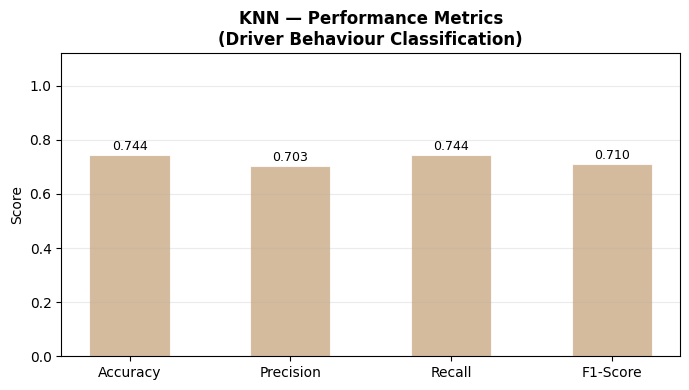

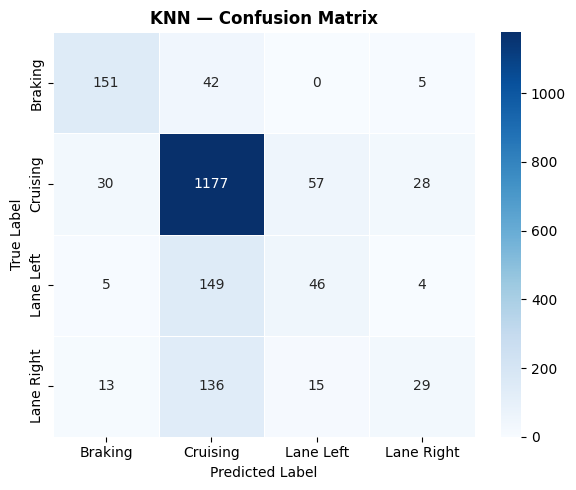

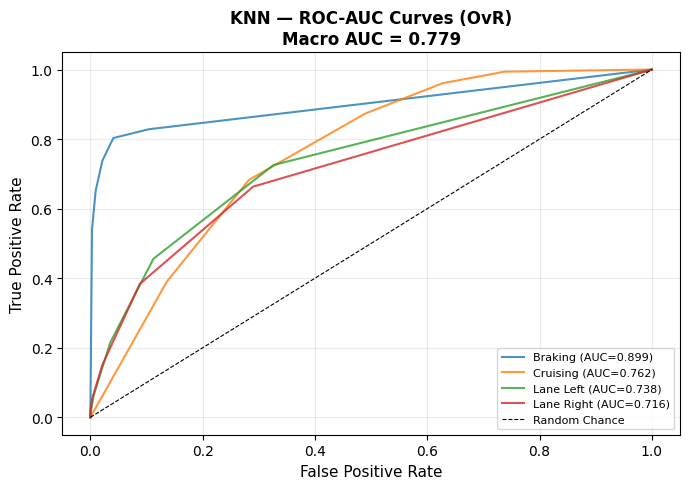


✅ KNN — Macro ROC-AUC: 0.7785


In [13]:

# ── 1. Metrics Bar Chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_vals  = [acc, prec, rec, f1]
bars = ax.bar(metric_names, metric_vals, color=MODEL_COLOR,
              alpha=0.78, edgecolor="white", linewidth=0.8, width=0.5)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title(f"{MODEL_NAME} — Performance Metrics\n(Driver Behaviour Classification)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_metrics.png", dpi=150)
plt.show()

# ── 2. Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title(f"{MODEL_NAME} — Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_confusion.png", dpi=150)
plt.show()

# ── 3. ROC-AUC Curve (One-vs-Rest, macro) ────────────────────────────────────
y_bin = label_binarize(y_test, classes=classes)
cls_list = list(model.classes_)
prob_aligned = np.zeros((len(y_test), len(classes)))
for ci, c in enumerate(classes):
    if c in cls_list:
        prob_aligned[:, ci] = y_prob[:, cls_list.index(c)]

fig, ax = plt.subplots(figsize=(7, 5))
for ci, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, ci], prob_aligned[:, ci])
    auc = roc_auc_score(y_bin[:, ci], prob_aligned[:, ci])
    ax.plot(fpr, tpr, linewidth=1.5,
            label=f"{cls} (AUC={auc:.3f})", alpha=0.8)
macro_auc = roc_auc_score(y_bin, prob_aligned, average="macro", multi_class="ovr")
ax.plot([0,1],[0,1],"k--",linewidth=0.8,label="Random Chance")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"{MODEL_NAME} — ROC-AUC Curves (OvR)\nMacro AUC = {macro_auc:.3f}",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_roc.png", dpi=150)
plt.show()

print(f"\n✅ {MODEL_NAME} — Macro ROC-AUC: {macro_auc:.4f}")


# Logistic Regression

## 1. Imports & Data Preprocessing

In [14]:

import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# ── Configuration (mirrors process_data.ipynb exactly) ───────────────────────
SEED        = 42
WINDOW_SIZE = 20
STEP_SIZE   = 5
DATA_PATH   = "trip_*.csv"   # adjust path as needed

# ── Load & preprocess all trip CSVs ──────────────────────────────────────────
files = glob.glob(DATA_PATH)
print(f"Found {len(files)} CSV files.")

all_samples = []
for fn in sorted(files):
    df = pd.read_csv(fn)
    df["mag"]       = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
    df["jerk"]      = df["mag"].diff().fillna(0)
    df["gps_speed"] = df["gps_speed"].fillna(0)
    for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        w = df.iloc[i : i + WINDOW_SIZE]
        label = w["label"].mode()[0]
        all_samples.append({
            "label":       label,
            "avg_speed":   float(w["gps_speed"].mean()),
            "max_force":   float(w["mag"].max()),
            "std_force":   float(w["mag"].std()),
            "min_force":   float(w["mag"].min()),
            "avg_jerk":    float(w["jerk"].abs().mean()),
            "avg_lateral": float(w["acc_y"].abs().mean()),
            "max_lateral": float(w["acc_y"].abs().max()),
        })

dfm = pd.DataFrame(all_samples)
print(f"Total windows: {len(dfm)}")
print("Class distribution:")
print(dfm["label"].value_counts())

# ── Feature / label split & train-test split ─────────────────────────────────
from sklearn.model_selection import train_test_split

X = dfm.drop(columns=["label"])
y = dfm["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")


Found 6 CSV files.
Total windows: 9433
Class distribution:
label
Cruising      6380
Lane Left     1091
Braking        985
Lane Right     977
Name: count, dtype: int64

Train: 7546  |  Test: 1887


## 2. Model Training

In [15]:

import time
from sklearn.linear_model import LogisticRegression

MODEL_NAME = "Logistic Regression"

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
model = LogisticRegression(max_iter=1000, random_state=SEED)
model.fit(X_train, y_train)
print(f"Training time: {time.time()-t0:.2f}s")


Training time: 0.31s


## 3. Evaluation & Visualizations

In [16]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# Muted color palette — designed so RF (forest green) stands out when comparing
MODEL_COLOR   = "#8faacc"   # this model
ACCENT_COLOR  = "#5b8db8"   # secondary accent
classes = sorted(y.unique().tolist())

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {{acc:.4f}}")
print(f"Precision : {{prec:.4f}}")
print(f"Recall    : {{rec:.4f}}")
print(f"F1-Score  : {{f1:.4f}}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy  : {acc:.4f}
Precision : {prec:.4f}
Recall    : {rec:.4f}
F1-Score  : {f1:.4f}

Detailed Classification Report:
              precision    recall  f1-score   support

     Braking       0.78      0.65      0.71       198
    Cruising       0.74      0.99      0.84      1292
   Lane Left       0.00      0.00      0.00       204
  Lane Right       0.00      0.00      0.00       193

    accuracy                           0.74      1887
   macro avg       0.38      0.41      0.39      1887
weighted avg       0.59      0.74      0.65      1887



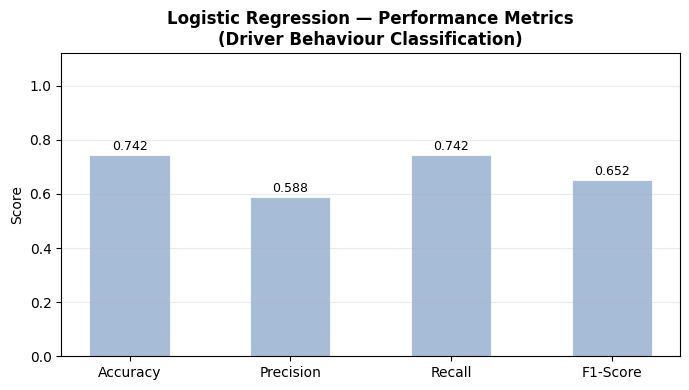

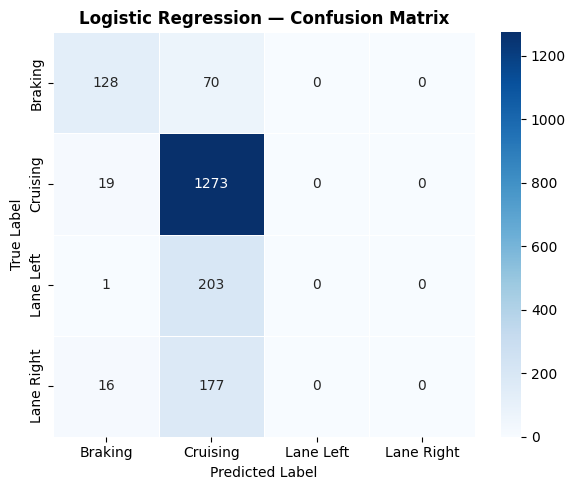

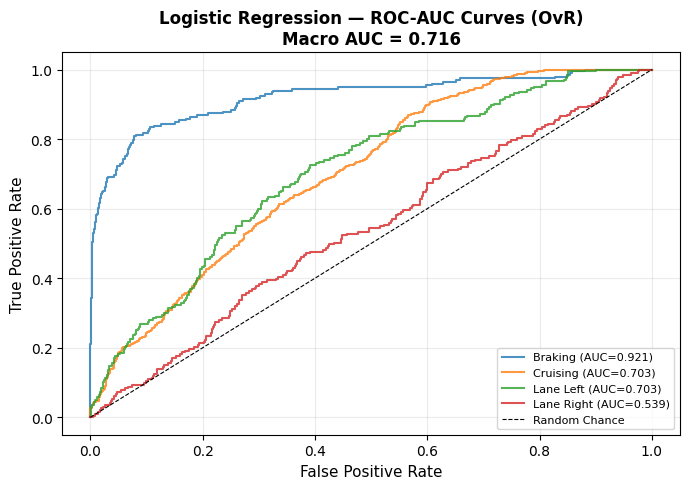


✅ Logistic Regression — Macro ROC-AUC: 0.7162


In [17]:

# ── 1. Metrics Bar Chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_vals  = [acc, prec, rec, f1]
bars = ax.bar(metric_names, metric_vals, color=MODEL_COLOR,
              alpha=0.78, edgecolor="white", linewidth=0.8, width=0.5)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title(f"{MODEL_NAME} — Performance Metrics\n(Driver Behaviour Classification)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_metrics.png", dpi=150)
plt.show()

# ── 2. Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title(f"{MODEL_NAME} — Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_confusion.png", dpi=150)
plt.show()

# ── 3. ROC-AUC Curve (One-vs-Rest, macro) ────────────────────────────────────
y_bin = label_binarize(y_test, classes=classes)
cls_list = list(model.classes_)
prob_aligned = np.zeros((len(y_test), len(classes)))
for ci, c in enumerate(classes):
    if c in cls_list:
        prob_aligned[:, ci] = y_prob[:, cls_list.index(c)]

fig, ax = plt.subplots(figsize=(7, 5))
for ci, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, ci], prob_aligned[:, ci])
    auc = roc_auc_score(y_bin[:, ci], prob_aligned[:, ci])
    ax.plot(fpr, tpr, linewidth=1.5,
            label=f"{cls} (AUC={auc:.3f})", alpha=0.8)
macro_auc = roc_auc_score(y_bin, prob_aligned, average="macro", multi_class="ovr")
ax.plot([0,1],[0,1],"k--",linewidth=0.8,label="Random Chance")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"{MODEL_NAME} — ROC-AUC Curves (OvR)\nMacro AUC = {macro_auc:.3f}",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_roc.png", dpi=150)
plt.show()

print(f"\n✅ {MODEL_NAME} — Macro ROC-AUC: {macro_auc:.4f}")


# Naïve Bayes

## 1. Imports & Data Preprocessing

In [22]:

import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# ── Configuration (mirrors process_data.ipynb exactly) ───────────────────────
SEED        = 42
WINDOW_SIZE = 20
STEP_SIZE   = 5
DATA_PATH   = "trip_*.csv"   # adjust path as needed

# ── Load & preprocess all trip CSVs ──────────────────────────────────────────
files = glob.glob(DATA_PATH)
print(f"Found {len(files)} CSV files.")

all_samples = []
for fn in sorted(files):
    df = pd.read_csv(fn)
    df["mag"]       = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
    df["jerk"]      = df["mag"].diff().fillna(0)
    df["gps_speed"] = df["gps_speed"].fillna(0)
    for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        w = df.iloc[i : i + WINDOW_SIZE]
        label = w["label"].mode()[0]
        all_samples.append({
            "label":       label,
            "avg_speed":   float(w["gps_speed"].mean()),
            "max_force":   float(w["mag"].max()),
            "std_force":   float(w["mag"].std()),
            "min_force":   float(w["mag"].min()),
            "avg_jerk":    float(w["jerk"].abs().mean()),
            "avg_lateral": float(w["acc_y"].abs().mean()),
            "max_lateral": float(w["acc_y"].abs().max()),
        })

dfm = pd.DataFrame(all_samples)
print(f"Total windows: {len(dfm)}")
print("Class distribution:")
print(dfm["label"].value_counts())

# ── Feature / label split & train-test split ─────────────────────────────────
from sklearn.model_selection import train_test_split

X = dfm.drop(columns=["label"])
y = dfm["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")


Found 6 CSV files.
Total windows: 9433
Class distribution:
label
Cruising      6380
Lane Left     1091
Braking        985
Lane Right     977
Name: count, dtype: int64

Train: 7546  |  Test: 1887


## 2. Model Training

In [23]:

import time
from sklearn.naive_bayes import GaussianNB

MODEL_NAME = "Naïve Bayes"

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
model = GaussianNB()
model.fit(X_train, y_train)
print(f"Training time: {time.time()-t0:.4f}s  (instantaneous)")


Training time: 0.0100s  (instantaneous)


## 3. Evaluation & Visualizations

In [24]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# Muted color palette — designed so RF (forest green) stands out when comparing
MODEL_COLOR   = "#c8c882"   # this model
ACCENT_COLOR  = "#5b8db8"   # secondary accent
classes = sorted(y.unique().tolist())

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {{acc:.4f}}")
print(f"Precision : {{prec:.4f}}")
print(f"Recall    : {{rec:.4f}}")
print(f"F1-Score  : {{f1:.4f}}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy  : {acc:.4f}
Precision : {prec:.4f}
Recall    : {rec:.4f}
F1-Score  : {f1:.4f}

Detailed Classification Report:
              precision    recall  f1-score   support

     Braking       0.49      0.77      0.60       198
    Cruising       0.75      0.85      0.80      1292
   Lane Left       0.26      0.12      0.16       204
  Lane Right       0.31      0.04      0.07       193

    accuracy                           0.68      1887
   macro avg       0.45      0.45      0.41      1887
weighted avg       0.63      0.68      0.63      1887



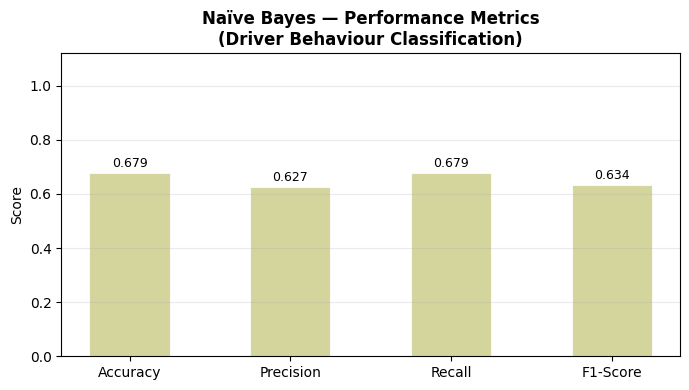

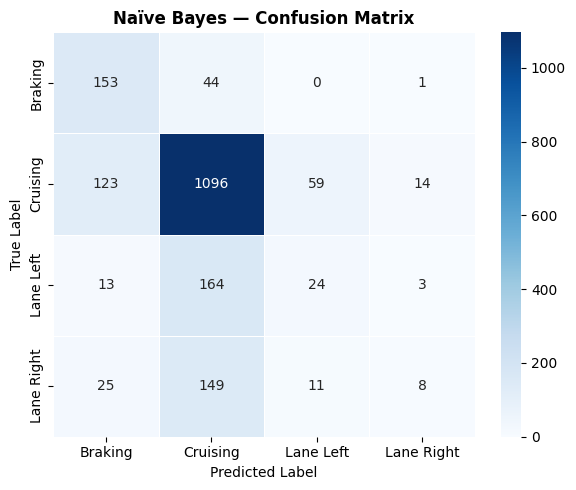

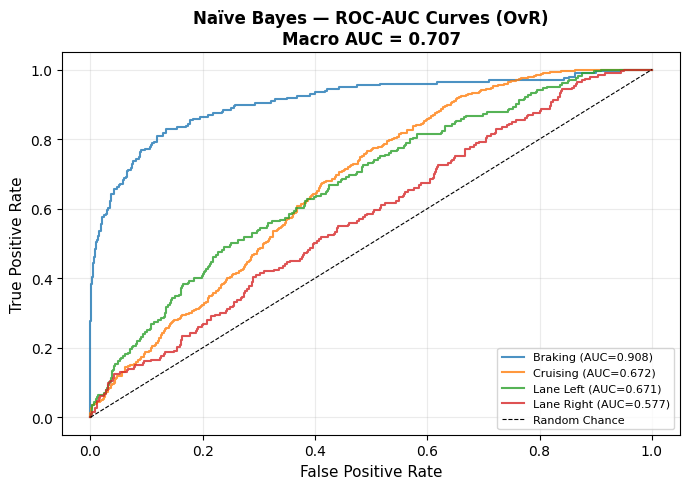


✅ Naïve Bayes — Macro ROC-AUC: 0.7073


In [25]:

# ── 1. Metrics Bar Chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_vals  = [acc, prec, rec, f1]
bars = ax.bar(metric_names, metric_vals, color=MODEL_COLOR,
              alpha=0.78, edgecolor="white", linewidth=0.8, width=0.5)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title(f"{MODEL_NAME} — Performance Metrics\n(Driver Behaviour Classification)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_metrics.png", dpi=150)
plt.show()

# ── 2. Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title(f"{MODEL_NAME} — Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_confusion.png", dpi=150)
plt.show()

# ── 3. ROC-AUC Curve (One-vs-Rest, macro) ────────────────────────────────────
y_bin = label_binarize(y_test, classes=classes)
cls_list = list(model.classes_)
prob_aligned = np.zeros((len(y_test), len(classes)))
for ci, c in enumerate(classes):
    if c in cls_list:
        prob_aligned[:, ci] = y_prob[:, cls_list.index(c)]

fig, ax = plt.subplots(figsize=(7, 5))
for ci, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, ci], prob_aligned[:, ci])
    auc = roc_auc_score(y_bin[:, ci], prob_aligned[:, ci])
    ax.plot(fpr, tpr, linewidth=1.5,
            label=f"{cls} (AUC={auc:.3f})", alpha=0.8)
macro_auc = roc_auc_score(y_bin, prob_aligned, average="macro", multi_class="ovr")
ax.plot([0,1],[0,1],"k--",linewidth=0.8,label="Random Chance")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"{MODEL_NAME} — ROC-AUC Curves (OvR)\nMacro AUC = {macro_auc:.3f}",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_roc.png", dpi=150)
plt.show()

print(f"\n✅ {MODEL_NAME} — Macro ROC-AUC: {macro_auc:.4f}")


# Support Vector Machine (SVM)

## 1. Imports & Data Preprocessing

In [30]:

import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# ── Configuration (mirrors process_data.ipynb exactly) ───────────────────────
SEED        = 42
WINDOW_SIZE = 20
STEP_SIZE   = 5
DATA_PATH   = "trip_*.csv"   # adjust path as needed

# ── Load & preprocess all trip CSVs ──────────────────────────────────────────
files = glob.glob(DATA_PATH)
print(f"Found {len(files)} CSV files.")

all_samples = []
for fn in sorted(files):
    df = pd.read_csv(fn)
    df["mag"]       = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
    df["jerk"]      = df["mag"].diff().fillna(0)
    df["gps_speed"] = df["gps_speed"].fillna(0)
    for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        w = df.iloc[i : i + WINDOW_SIZE]
        label = w["label"].mode()[0]
        all_samples.append({
            "label":       label,
            "avg_speed":   float(w["gps_speed"].mean()),
            "max_force":   float(w["mag"].max()),
            "std_force":   float(w["mag"].std()),
            "min_force":   float(w["mag"].min()),
            "avg_jerk":    float(w["jerk"].abs().mean()),
            "avg_lateral": float(w["acc_y"].abs().mean()),
            "max_lateral": float(w["acc_y"].abs().max()),
        })

dfm = pd.DataFrame(all_samples)
print(f"Total windows: {len(dfm)}")
print("Class distribution:")
print(dfm["label"].value_counts())

# ── Feature / label split & train-test split ─────────────────────────────────
from sklearn.model_selection import train_test_split

X = dfm.drop(columns=["label"])
y = dfm["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")

Found 6 CSV files.
Total windows: 9433
Class distribution:
label
Cruising      6380
Lane Left     1091
Braking        985
Lane Right     977
Name: count, dtype: int64

Train: 7546  |  Test: 1887


## 2. Model Training

In [31]:

import time
from sklearn.svm import SVC

MODEL_NAME = "SVM"

# ── Train ─────────────────────────────────────────────────────────────────────
# probability=True required for ROC-AUC curves (uses Platt scaling internally)
t0 = time.time()
model = SVC(kernel="rbf", probability=True, random_state=SEED)
model.fit(X_train, y_train)
print(f"Training time: {time.time()-t0:.2f}s  (SVM is slow on large datasets)")

Training time: 9.30s  (SVM is slow on large datasets)


## 3. Evaluation & Visualizations

In [32]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# Muted color palette — designed so RF (forest green) stands out when comparing
MODEL_COLOR   = "#82b4c8"   # this model
ACCENT_COLOR  = "#5b8db8"   # secondary accent
classes = sorted(y.unique().tolist())

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {{acc:.4f}}")
print(f"Precision : {{prec:.4f}}")
print(f"Recall    : {{rec:.4f}}")
print(f"F1-Score  : {{f1:.4f}}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy  : {acc:.4f}
Precision : {prec:.4f}
Recall    : {rec:.4f}
F1-Score  : {f1:.4f}

Detailed Classification Report:
              precision    recall  f1-score   support

     Braking       0.80      0.60      0.68       198
    Cruising       0.73      0.99      0.84      1292
   Lane Left       0.00      0.00      0.00       204
  Lane Right       0.00      0.00      0.00       193

    accuracy                           0.74      1887
   macro avg       0.38      0.40      0.38      1887
weighted avg       0.59      0.74      0.65      1887



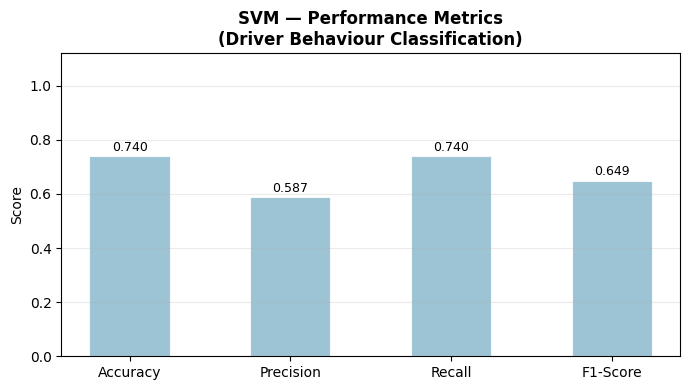

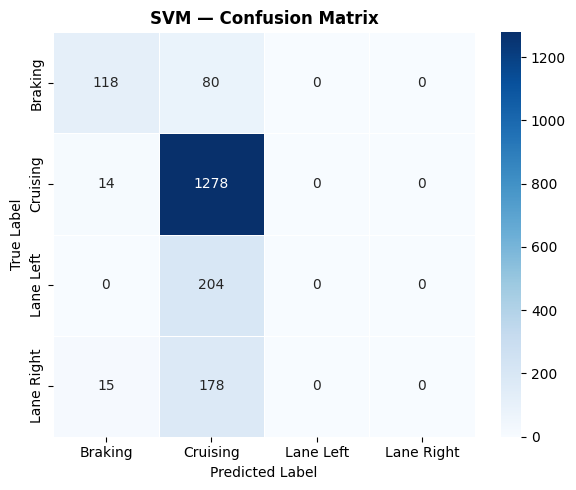

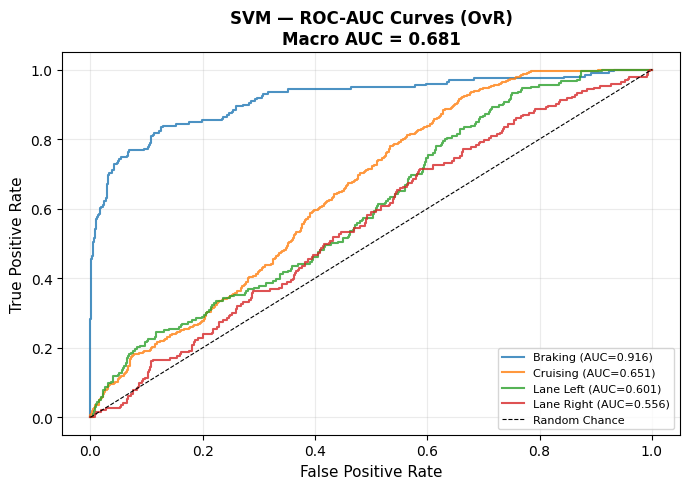


✅ SVM — Macro ROC-AUC: 0.6809


In [33]:

# ── 1. Metrics Bar Chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_vals  = [acc, prec, rec, f1]
bars = ax.bar(metric_names, metric_vals, color=MODEL_COLOR,
              alpha=0.78, edgecolor="white", linewidth=0.8, width=0.5)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title(f"{MODEL_NAME} — Performance Metrics\n(Driver Behaviour Classification)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_metrics.png", dpi=150)
plt.show()

# ── 2. Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title(f"{MODEL_NAME} — Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_confusion.png", dpi=150)
plt.show()

# ── 3. ROC-AUC Curve (One-vs-Rest, macro) ────────────────────────────────────
y_bin = label_binarize(y_test, classes=classes)
cls_list = list(model.classes_)
prob_aligned = np.zeros((len(y_test), len(classes)))
for ci, c in enumerate(classes):
    if c in cls_list:
        prob_aligned[:, ci] = y_prob[:, cls_list.index(c)]

fig, ax = plt.subplots(figsize=(7, 5))
for ci, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, ci], prob_aligned[:, ci])
    auc = roc_auc_score(y_bin[:, ci], prob_aligned[:, ci])
    ax.plot(fpr, tpr, linewidth=1.5,
            label=f"{cls} (AUC={auc:.3f})", alpha=0.8)
macro_auc = roc_auc_score(y_bin, prob_aligned, average="macro", multi_class="ovr")
ax.plot([0,1],[0,1],"k--",linewidth=0.8,label="Random Chance")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"{MODEL_NAME} — ROC-AUC Curves (OvR)\nMacro AUC = {macro_auc:.3f}",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MODEL_NAME.replace(' ','_').lower()}_roc.png", dpi=150)
plt.show()

print(f"\n✅ {MODEL_NAME} — Macro ROC-AUC: {macro_auc:.4f}")